<a href="https://colab.research.google.com/github/finaindahs99-stack/pemrograman-python/blob/main/stat_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Library
import numpy as np
import pandas as pd
import statsmodels.api as sm
# Membuat DataFrame dari data yang diberikan
data = {
'Partisipan': np.arange(1, 11),
'PMakan': [50, 40, 60, 55, 45, 65, 70, 75, 80, 90],
'PTranspor': [20, 25, 30, 35, 40, 50, 55, 60, 65, 70],
'BB': [60, 55, 65, 70, 62, 75, 80, 85, 90, 95]}
df = pd.DataFrame(data)
# Memisahkan variabel independen dan dependen
X = df[['PMakan', 'PTranspor']]
y = df['BB']
X = sm.add_constant(X) # Menambahkan kolom konstanta untuk intercept
model = sm.OLS(y, X) # Membangun model regresi
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                     BB   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     234.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           3.85e-07
Time:                        00:18:38   Log-Likelihood:                -18.626
No. Observations:                  10   AIC:                             43.25
Df Residuals:                       7   BIC:                             44.16
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.9870      2.879      9.374      0.0

In [ ]:

import numpy as np
import pandas as pd
import statsmodels.api as sm
import plotly.graph_objects as go

# 1. MEMBUAT DATA
data = {
    "Partisipan": np.arange(1, 11),
    "Peng Makanan": [50, 40, 60, 55, 45, 65, 70, 75, 80, 990],
    "Peng Transportasi": [20, 25, 30, 35, 40, 50, 55, 60, 65, 70],
    "Berat Badan": [60, 55, 65, 70, 62, 75, 80, 85, 90, 95]
}

df = pd.DataFrame(data)

# 2. MENENTUKAN VARIABEL INDEPENDEN (X)
X = df[["Peng Makanan", "Peng Transportasi"]]

# 3. MENENTUKAN VARIABEL DEPENDEN (Y)
y = df["Berat Badan"]

# 4. MENAMBAHKAN INTERCEPT
X_model = sm.add_constant(X)

# 5. ESTIMASI MODEL OLS
model = sm.OLS(y, X_model)
results = model.fit()

# 6. MENAMPILKAN RINGKASAN HASIL REGRESI
print("\n")
print("=" * 70)
print("HASIL REGRESI LINEAR BERGANDA")
print("=" * 70)

print(results.summary())

# 7. MENGAMBIL KOEFISIEN REGRESI
intercept = results.params["const"]
coef_makanan = results.params["Peng Makanan"]
coef_transportasi = results.params["Peng Transportasi"]

r_squared = results.rsquared
adjusted_r_squared = results.rsquared_adj

# 8. MEMBUAT PERSAMAAN REGRESI
persamaan = (
    f"Ŷ = {intercept:.3f}"
    f" + ({coef_makanan:.3f}) X1"
    f" + ({coef_transportasi:.3f}) X2"
)

print("\n")
print("=" * 70)
print("PERSAMAAN REGRESI")
print("=" * 70)

print(persamaan)
print(f"\nR2 = {r_squared:.4f}")
print(f"Adjusted R2 = {adjusted_r_squared:.4f}")

# 9. MENGHITUNG NILAI PREDIKSI
df["Prediksi"] = results.predict(X_model)

print("\n")
print("=" * 70)
print("DATA AKTUAL & PREDIKSI")
print("=" * 70)

print(
    df[
        [
            "Partisipan",
            "Peng Makanan",
            "Peng Transportasi",
            "Berat Badan",
            "Prediksi"
        ]
    ].round(2).to_string(index=False)
)

# 10. MEMBUAT GRID UNTUK BIDANG REGRESI
x1 = np.linspace(
    df["Peng Makanan"].min(),
    df["Peng Makanan"].max(),
    40
)

x2 = np.linspace(
    df["Peng Transportasi"].min(),
    df["Peng Transportasi"].max(),
    40
)

X1, X2 = np.meshgrid(x1, x2)

# 11. MENGHITUNG NILAI Y PADA BIDANG REGRESI
Y = (
    intercept
    + coef_makanan * X1
    + coef_transportasi * X2
)

# 12. MEMBUAT FIGURE 3D
fig = go.Figure()

# 13. MENAMPILKAN DATA AKTUAL
fig.add_trace(
    go.Scatter3d(
        x=df["Peng Makanan"],
        y=df["Peng Transportasi"],
        z=df["Berat Badan"],
        mode="markers",
        marker=dict(
            size=7,
            color="red",
            opacity=0.9
        ),
        name="Data Aktual",
        text=[
            f"Partisipan {p}"
            for p in df["Partisipan"]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Peng. Makanan: %{x}<br>"
            "Peng. Transportasi: %{y}<br>"
            "Berat Badan: %{z}"
            "<extra></extra>"
        )
    )
)

# 14. MENAMPILKAN BIDANG REGRESI
fig.add_trace(
    go.Surface(
        x=X1,
        y=X2,
        z=Y,
        opacity=0.60,
        colorscale="Viridis",
        name="Regression Plane",
        hovertemplate=(
            "Peng. Makanan: %{x:.2f}<br>"
            "Peng. Transportasi: %{y:.2f}<br>"
            "Prediksi Y: %{z:.2f}"
            "<extra></extra>"
        )
    )
)

# 15. MENGATUR TAMPILAN GRAFIK
fig.update_layout(
    title={
        "text": (
            "REGRESI LINEAR BERGANDA 3D"
            "<br>"
            f"<sup>{persamaan} | "
            f"R2 = {r_squared:.3f}</sup>"
        ),
        "x": 0.5
    },
    scene={
        "xaxis": {
            "title": "Pengeluaran Makanan (X1)"
        },
        "yaxis": {
            "title": "Pengeluaran Transportasi (X2)"
        },
        "zaxis": {
            "title": "Berat Badan (Y)"
        }
    },
    width=1000,
    height=750,
    margin={
        "l": 0,
        "r": 0,
        "b": 0,
        "t": 100
    },
    legend={
        "x": 0.02,
        "y": 0.98
    }
)

# 16. MENAMPILKAN GRAFIK
fig.show()



HASIL REGRESI LINEAR BERGANDA
                            OLS Regression Results                            
Dep. Variable:            Berat Badan   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     42.50
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           0.000121
Time:                        00:22:23   Log-Likelihood:                -26.846
No. Observations:                  10   AIC:                             59.69
Df Residuals:                       7   BIC:                             60.60
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const 

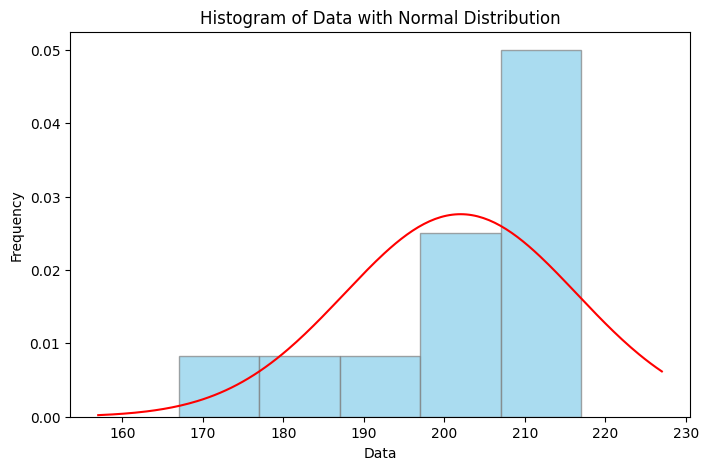

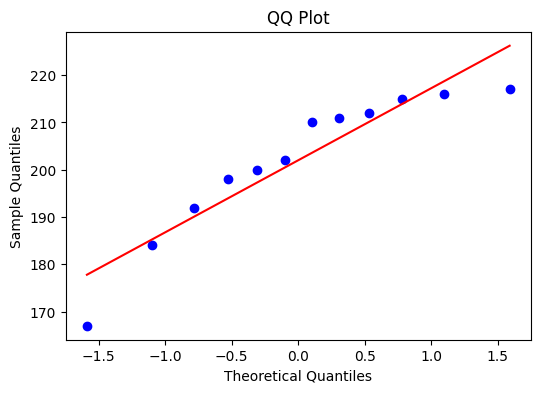

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Data
# Masukkan seluruh data lengkap dari sumber Statext
data = np.array([
    167, 184, 192, 198, 200, 202,
    210, 211, 212, 215, 216, 217
    # Lanjutkan data lainnya di sini
])

# Histogram
plt.figure(figsize=(8, 5))

plt.hist(
    data,
    bins='auto',
    density=True,
    alpha=0.7,
    color='skyblue',
    edgecolor='gray'
)

# Kurva distribusi normal
mu = np.mean(data)
std = np.std(data, ddof=0)

x = np.linspace(
    np.min(data) - 10,
    np.max(data) + 10,
    200
)

y = stats.norm.pdf(x, mu, std)

plt.plot(x, y, color='red')

plt.title('Histogram of Data with Normal Distribution')
plt.xlabel('Data')
plt.ylabel('Frequency')

plt.show()

# QQ Plot
plt.figure(figsize=(6, 4))

stats.probplot(
    data,
    dist="norm",
    plot=plt
)

plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

plt.show()

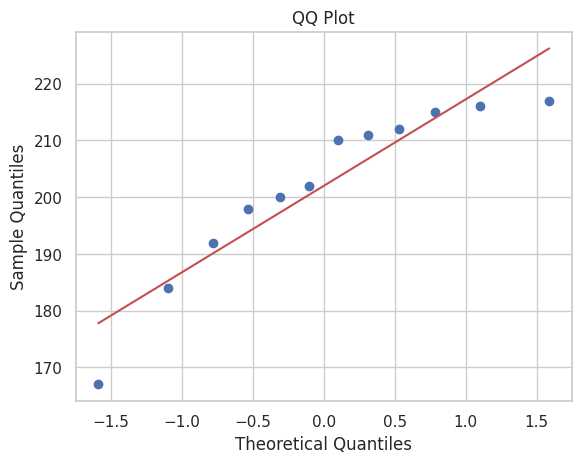

<Figure size 600x400 with 0 Axes>

In [ ]:

import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

# Memasukkan data
data = np.array([
    167, 184, 192, 198, 200, 202,
    210, 211, 212, 215, 216, 217
])

# Mengatur tampilan grafik
sns.set(style="whitegrid")

# Membuat QQ Plot
stats.probplot(
    data,
    dist="norm",
    plot=plt
)

# Mengatur judul dan label
plt.title("QQ Plot")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")

# Mengatur ukuran grafik
plt.figure(figsize=(6, 4))

# Menampilkan grafik
plt.show()

In [ ]:

import numpy as np
from scipy import stats

# 1. MEMASUKKAN DATA
data = np.array([
    167, 184, 192, 198, 200, 202,
    210, 211, 212, 215, 216, 217
])

# 2. KOLOMOGOROV-SMIRNOV TEST
# Data distandarisasi terlebih dahulu
z_data = (data - np.mean(data)) / np.std(data, ddof=1)

ks_statistic, ks_pvalue = stats.kstest(
    z_data, 'norm'
)

print("Kolmogorov-Smirnov Test:")
print("Test Statistic:", ks_statistic)
print("p-value:", ks_pvalue)

# 3. SHAPIRO-WILK TEST
sw_statistic, sw_pvalue = stats.shapiro(data)

print("\nShapiro-Wilk Test:")
print("Test Statistic:", sw_statistic)
print("p-value:", sw_pvalue)

# 4. JARQUE-BERA TEST
jb_statistic, jb_pvalue = stats.jarque_bera(data)

print("\nJarque-Bera Test:")
print("Test Statistic:", jb_statistic)
print("p-value:", jb_pvalue)

# 5. KESIMPULAN UJI NORMALITAS
alpha = 0.05

print("\nKESIMPULAN UJI NORMALITAS")
print("=" * 40)

if ks_pvalue > alpha:
    print("Kolmogorov-Smirnov: Data berdistribusi normal")
else:
    print("Kolmogorov-Smirnov: Data tidak berdistribusi normal")

if sw_pvalue > alpha:
    print("Shapiro-Wilk: Data berdistribusi normal")
else:
    print("Shapiro-Wilk: Data tidak berdistribusi normal")

if jb_pvalue > alpha:
    print("Jarque-Bera: Data berdistribusi normal")
else:
    print("Jarque-Bera: Data tidak berdistribusi normal")

Kolmogorov-Smirnov Test:
Test Statistic: 0.20202582478193354
p-value: 0.6411213647439062

Shapiro-Wilk Test:
Test Statistic: 0.8781440854620193
p-value: 0.08298105386096202

Jarque-Bera Test:
Test Statistic: 2.4154126565554366
p-value: 0.29888203109494

KESIMPULAN UJI NORMALITAS
Kolmogorov-Smirnov: Data berdistribusi normal
Shapiro-Wilk: Data berdistribusi normal
Jarque-Bera: Data berdistribusi normal


UJI NORMALITAS

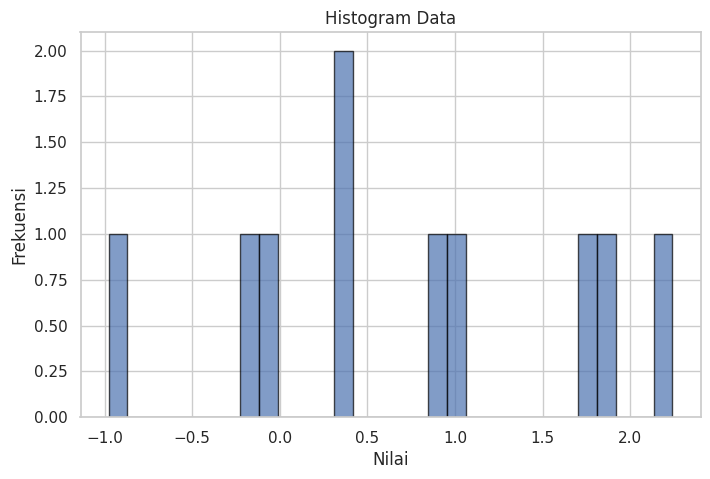

In [ ]:

# Uji normalitas

import numpy as np
import matplotlib.pyplot as plt

# 1. Generate random data
np.random.seed(0)

tahun = np.arange(1, 11)  # Variabel independen tahun

var1 = np.random.normal(0, 1, 10)  # Variabel independen 1

# 2. Membuat histogram
plt.figure(figsize=(8, 5))

plt.hist(
    var1,
    bins=30,
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('Nilai')
plt.ylabel('Frekuensi')
plt.title('Histogram Data')
plt.grid(True)

# 3. Menampilkan grafik
plt.show()

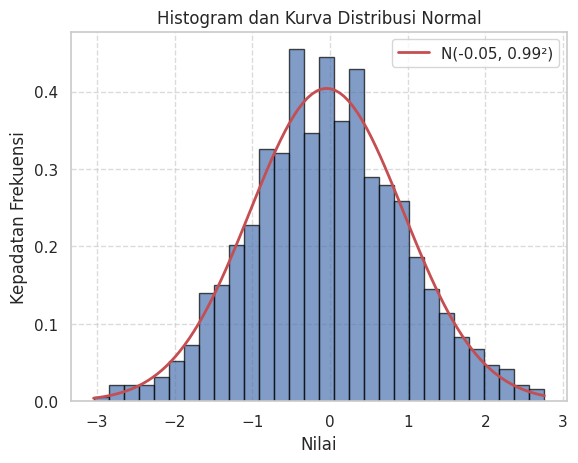

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate random data
np.random.seed(0)

tahun = np.arange(1, 11)
var1 = np.random.normal(0, 1, 1000)

# Hitung mean dan standar deviasi
mu = np.mean(var1)
sigma = np.std(var1)

# Plot histogram
count, bins, ignored = plt.hist(
    var1,
    bins=30,
    density=True,
    edgecolor='black',
    alpha=0.7
)

# Plot kurva distribusi normal
x = np.linspace(min(bins), max(bins), 100)

pdf = norm.pdf(x, mu, sigma)

plt.plot(
    x,
    pdf,
    'r-',
    linewidth=2,
    label=f'N({mu:.2f}, {sigma:.2f}²)'
)

# Tambahkan judul dan label
plt.xlabel('Nilai')
plt.ylabel('Kepadatan Frekuensi')
plt.title('Histogram dan Kurva Distribusi Normal')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Tampilkan grafik
plt.show()

In [ ]:
import scipy.stats as stats

# Uji normalitas data
statistic, p_value = stats.shapiro(var1)

# Cetak hasil uji normalitas
alpha = 0.05

if p_value > alpha:
    print("Data terdistribusi normal")
else:
    print("Data tidak terdistribusi normal")

Data terdistribusi normal


Koefisien Regresi:
Beta0: 0.1915
Beta1: 1.9668
Beta2: 3.0571


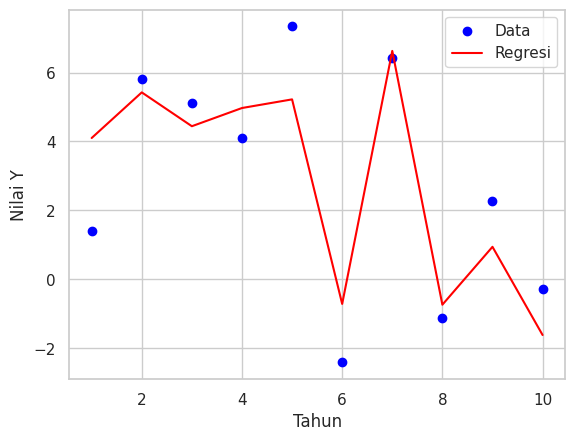

In [ ]:

# REGRESI UJI ASUMSI KLASIK

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generate random data
np.random.seed(0)

tahun = np.arange(1, 11)

var1 = np.random.normal(0, 1, 10)
var2 = np.random.normal(0, 1, 10)

nilai_y = (
    2 * var1
    + 3 * var2
    + np.random.normal(0, 1, 10)
)

# Perform linear regression
X = np.column_stack((var1, var2))

# Tambahkan kolom intercept
X = np.column_stack((np.ones(len(tahun)), X))

# Menghitung koefisien regresi
beta = np.linalg.inv(X.T @ X) @ X.T @ nilai_y

print("Koefisien Regresi:")

for i in range(len(beta)):
    print(f"Beta{i}: {beta[i]:.4f}")

# Prediksi dan residual
y_pred = X @ beta
residual = nilai_y - y_pred

# Plot data dan regresi
fig, ax = plt.subplots()

ax.scatter(tahun, nilai_y, color='blue', label='Data')
ax.plot(tahun, y_pred, color='red', label='Regresi')

ax.set_xlabel('Tahun')
ax.set_ylabel('Nilai Y')
ax.legend()

plt.show()

UJI AUTOKORELASI

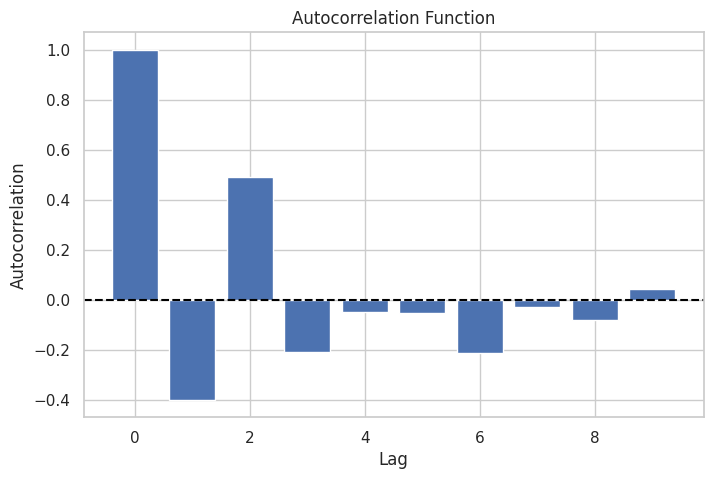

In [ ]:

# Uji Autokorelasi

import statsmodels.api as sm
import matplotlib.pyplot as plt

# Menghitung ACF
acf = sm.tsa.acf(nilai_y, nlags=9)

# Membuat grafik ACF
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(range(len(acf)), acf)

# Garis horizontal pada nol
ax.axhline(y=0, color='black', linestyle='--')

# Label dan judul
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation Function')

plt.grid(True)
plt.show()

HETEROSKEDASTISITAS: UJI WHITE

In [ ]:

# HETEROSKEDASTISITAS: UJI WHITE

import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white

# Fit model regresi
X = sm.add_constant(
    np.column_stack((var1, var2))
)

model = sm.OLS(nilai_y, X).fit()

# Hitung heteroskedastisitas
white_stat, white_pvalue, f_stat, f_pvalue = het_white(
    model.resid,
    X
)

# Cetak hasil uji heteroskedastisitas
print("UJI HETEROSKEDASTISITAS: UJI WHITE")
print("White Statistic:", white_stat)
print("p-value:", white_pvalue)
print("F Statistic:", f_stat)
print("F p-value:", f_pvalue)

# Tingkat signifikansi
alpha = 0.05

if white_pvalue > alpha:
    print("Tidak ada bukti heteroskedastisitas")
else:
    print("Ada bukti heteroskedastisitas")

UJI HETEROSKEDASTISITAS: UJI WHITE
White Statistic: 3.277970800857748
p-value: 0.6572159935877571
F Statistic: 0.39011681785327856
F p-value: 0.8350965673748434
Tidak ada bukti heteroskedastisitas


Multikolonieritas

In [ ]:
# UJI MULTIKOLINEARITAS

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Buat data contoh dengan multikolinearitas
np.random.seed(42)
n = 100

# Variabel independen
X1 = np.random.rand(n) * 10

# X2 sangat berkorelasi dengan X1
X2 = 2 * X1 + np.random.normal(0, 1, n)

X3 = np.random.rand(n) * 10

# Variabel dependen
Y = (
    3 + 2 * X1 + 1.5 * X2
    + 0.5 * X3
    + np.random.normal(0, 2, n)
)

# 2. Gabungkan menjadi DataFrame
df = pd.DataFrame({
    'Y': Y,
    'X1': X1,
    'X2': X2,
    'X3': X3
})

# 3. Hitung Variance Inflation Factor (VIF)
X = sm.add_constant(df[['X1', 'X2', 'X3']])

vif_data = pd.DataFrame()

vif_data["Variabel"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# 4. Tampilkan hasil
print("HASIL UJI MULTIKOLINEARITAS")
print(vif_data.round(5))

# 5. Interpretasi
print("\nKESIMPULAN")

for i in range(1, X.shape[1]):
    nama = X.columns[i]
    vif = vif_data.loc[i, "VIF"]

    if vif < 10:
        print(f"{nama}: Tidak ada indikasi multikolinearitas kuat")
    else:
        print(f"{nama}: Terdapat indikasi multikolinearitas")

HASIL UJI MULTIKOLINEARITAS
  Variabel       VIF
0    const   1.00000
1       X1  42.82380
2       X2  42.79832
3       X3   1.00843

KESIMPULAN
X1: Terdapat indikasi multikolinearitas
X2: Terdapat indikasi multikolinearitas
X3: Tidak ada indikasi multikolinearitas kuat


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    "https://raw.githubusercontent.com/Alam-A99/Case-Study/main/")

df.head()

HTTPError: HTTP Error 404: Not Found